## What is a Correlogram?

A correlogram is a visualization of correlations, typically:

Types of correlograms:

Correlation matrix correlogram (heatmap-style)

Pairwise scatter correlogram

Autocorrelation correlogram (time-series lag plot)

Partial autocorrelation correlogram (PACF)

Lagged cross-correlation correlogram

Clustered correlogram

Bubble-style correlogram

### PART 1 — Classic Correlogram (Scatter + Histogram Matrix)

This is the most traditional meaning of a correlogram in statistics.

1. Pairwise Scatter Correlogram (Seaborn pairplot)

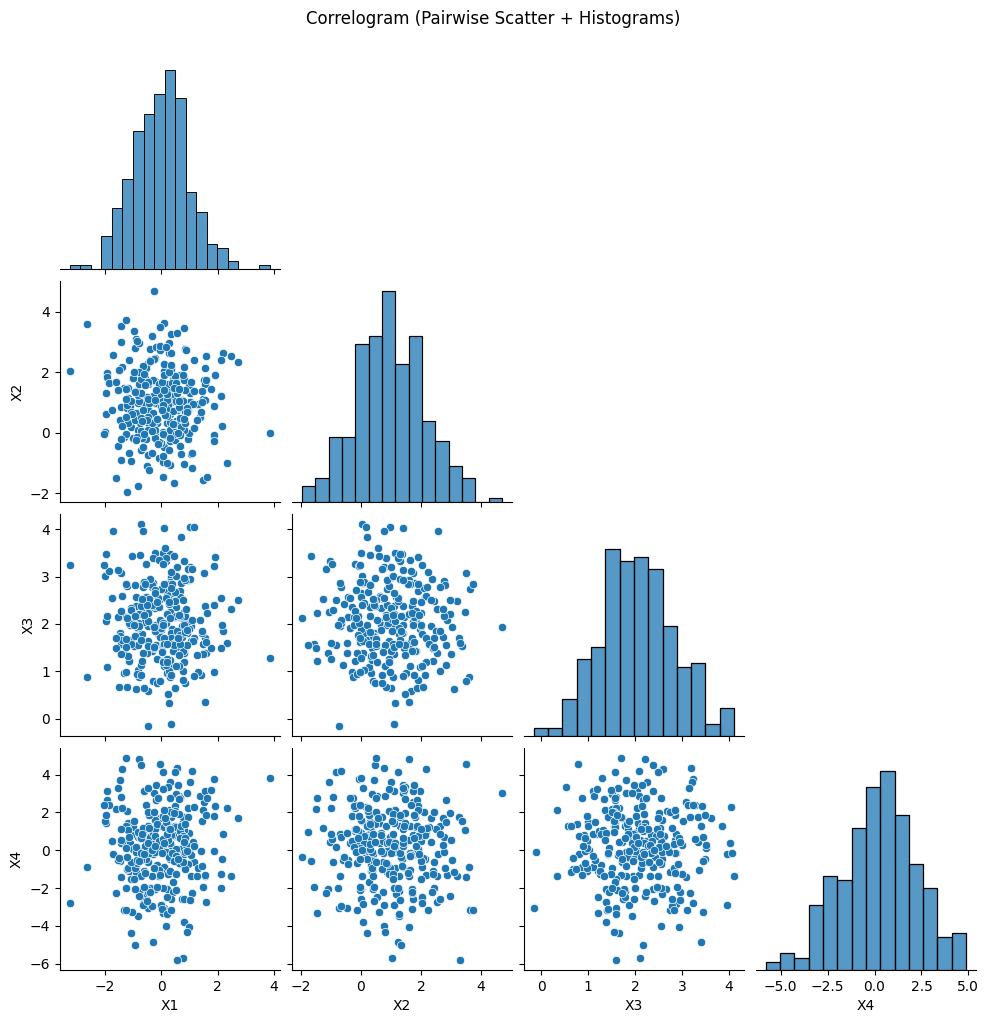

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.DataFrame({
    "X1": np.random.normal(0, 1, 300),
    "X2": np.random.normal(1, 1.2, 300),
    "X3": np.random.normal(2, 0.8, 300),
    "X4": np.random.normal(0, 2, 300),
})

sns.pairplot(
    df,
    kind="scatter",
    diag_kind="hist",
    corner=True
)

plt.suptitle("Correlogram (Pairwise Scatter + Histograms)", y=1.02)
plt.show()


### PART 2 — Advanced Correlogram with KDE & Regression

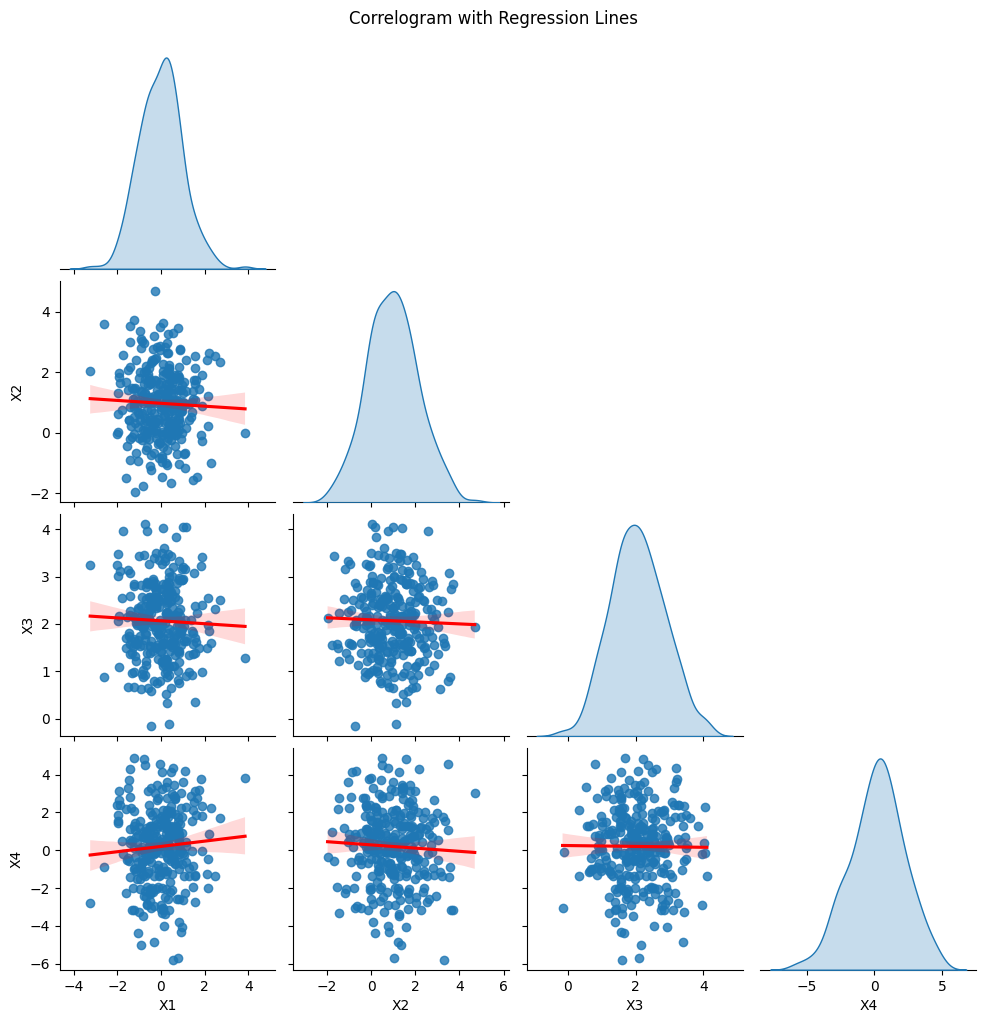

In [2]:
sns.pairplot(
    df,
    kind="reg",
    diag_kind="kde",
    plot_kws={"line_kws": {"color": "red"}},
    corner=True
)

plt.suptitle("Correlogram with Regression Lines", y=1.02)
plt.show()


### PART 3 — Correlation Coefficient Annotated Correlogram

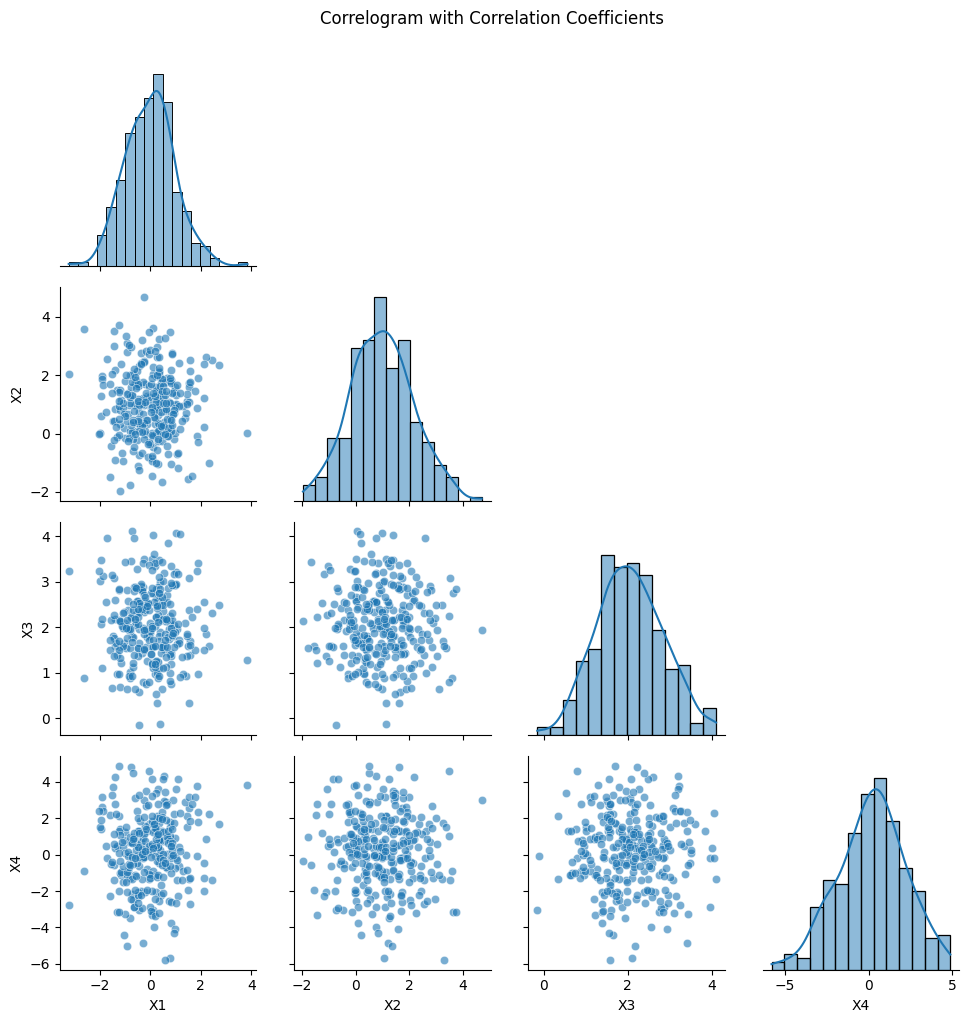

In [3]:
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}", xy=(.5, .5), xycoords=ax.transAxes,
                ha='center', va='center', fontsize=12)

g = sns.PairGrid(df, corner=True)

g.map_lower(sns.scatterplot, alpha=0.6)
g.map_diag(sns.histplot, kde=True)
g.map_upper(corrfunc)

plt.suptitle("Correlogram with Correlation Coefficients", y=1.02)
plt.show()


### PART 4 — Heatmap-Based Correlogram (Matrix View)

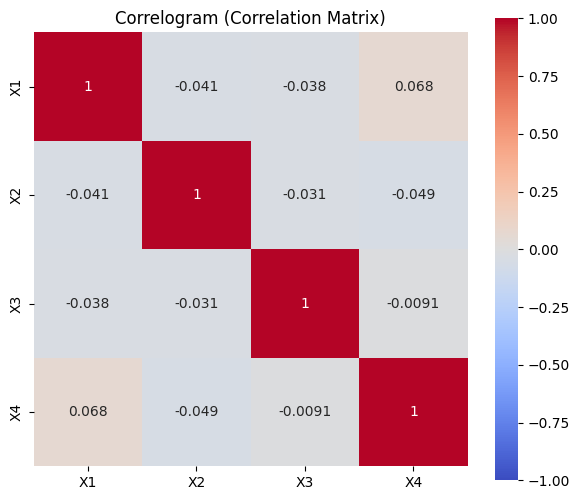

In [4]:
corr = df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlogram (Correlation Matrix)")
plt.show()


### PART 5 — Bubble Correlogram (Correlation as Circle Size)

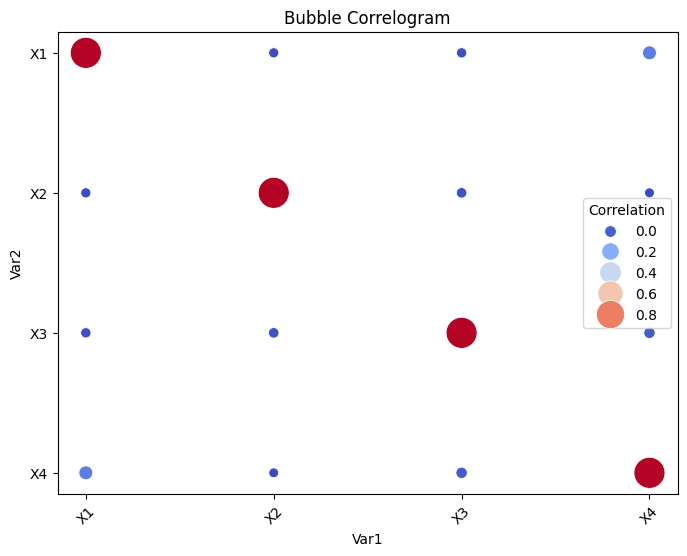

In [5]:
corr = df.corr()
corr_long = corr.stack().reset_index()
corr_long.columns = ["Var1", "Var2", "Correlation"]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=corr_long,
    x="Var1",
    y="Var2",
    size="Correlation",
    hue="Correlation",
    sizes=(50, 500),
    palette="coolwarm",
    legend="brief"
)

plt.xticks(rotation=45)
plt.title("Bubble Correlogram")
plt.show()


### PART 6 — Clustered Correlogram (Hierarchical)

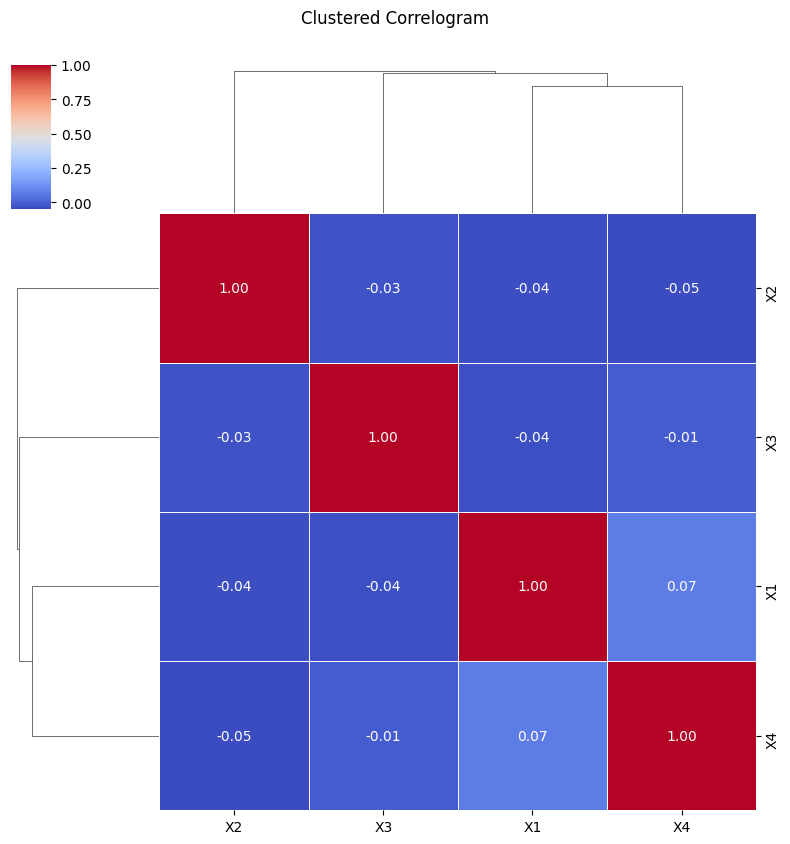

In [6]:
sns.clustermap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    figsize=(8, 8)
)

plt.suptitle("Clustered Correlogram", y=1.05)
plt.show()


### PART 7 — Time-Series Correlogram (Autocorrelation)
Autocorrelation Function (ACF)

<Figure size 800x400 with 0 Axes>

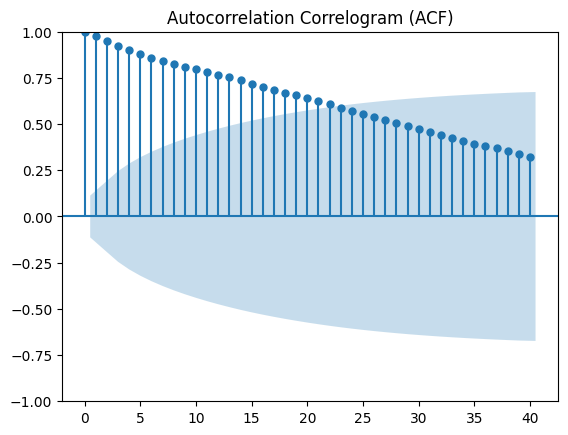

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

time_series = np.cumsum(np.random.randn(300))

plt.figure(figsize=(8, 4))
plot_acf(time_series, lags=40)
plt.title("Autocorrelation Correlogram (ACF)")
plt.show()


### PART 8 — Partial Autocorrelation (PACF)

<Figure size 800x400 with 0 Axes>

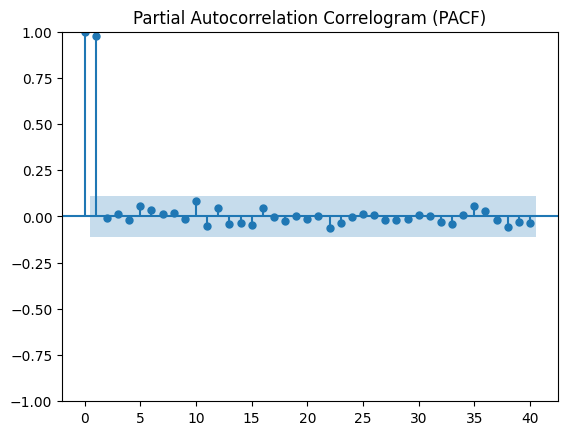

In [8]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(8, 4))
plot_pacf(time_series, lags=40, method="ywm")
plt.title("Partial Autocorrelation Correlogram (PACF)")
plt.show()


### PART 9 — Lagged Cross-Correlation Correlogram

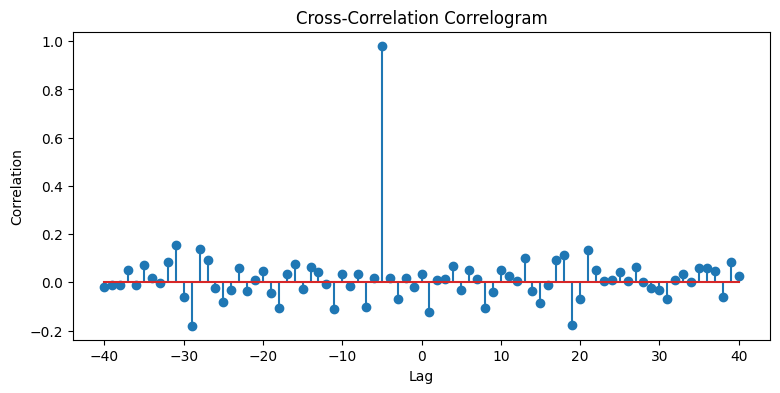

In [9]:
def cross_corr(x, y, lag=40):
    lags = range(-lag, lag + 1)
    corr = [np.corrcoef(x[max(0, k):len(x)+min(0, k)],
                        y[max(0, -k):len(y)+min(0, -k)])[0, 1]
            for k in lags]
    return lags, corr


x = np.random.randn(300)
y = np.roll(x, 5) + np.random.normal(0, 0.2, 300)

lags, corr_vals = cross_corr(x, y)

plt.figure(figsize=(9, 4))
plt.stem(lags, corr_vals)
plt.title("Cross-Correlation Correlogram")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()


### PART 10 — Publication-Ready Correlogram Function

In [10]:
def correlogram(df, method="pearson", style="heatmap"):
    corr = df.corr(method=method)

    if style == "heatmap":
        sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
        plt.title("Correlogram")
        plt.show()

    elif style == "cluster":
        sns.clustermap(corr, cmap="coolwarm", annot=True)
        plt.show()

    elif style == "bubble":
        c = corr.stack().reset_index()
        c.columns = ["X", "Y", "Corr"]
        sns.scatterplot(
            data=c,
            x="X",
            y="Y",
            size="Corr",
            hue="Corr",
            palette="coolwarm"
        )
        plt.title("Bubble Correlogram")
        plt.show()
